## Learning Goals

- Load and inspect a real-world dataset
- Detect missing values
- Measure missing-value percentages
- Understand which columns need attention
- Compare dropping vs imputation
- Impute numerical and categorical features
- Understand why `Cabin` needs a different decision
- Avoid data leakage in ML preprocessing
- Save a cleaned dataset that can be reused for **Outliers → Encoding → Scaling → Feature Engineering**

## 1. Import Libraries

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Load the Kaggle Dataset

Download `train.csv` from the Kaggle Titanic competition and place it in the same directory as this notebook.

Expected structure:

```text
03-Data-Preprocessing/
└── Missing-Values/
    ├── missing_values.ipynb
└── Datasets/
    └── train.csv
```

The Kaggle training set has **891 rows and 12 columns**.

In [77]:
df = pd.read_csv("../dataset/Titanic_original.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Understand the Dataset

In [91]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


### Important Columns

| Column | Meaning |
|---|---|
| `Survived` | Target: 0 = No, 1 = Yes |
| `Pclass` | Passenger class |
| `Sex` | Passenger sex |
| `Age` | Age in years |
| `SibSp` | Siblings/spouses aboard |
| `Parch` | Parents/children aboard |
| `Fare` | Passenger fare |
| `Cabin` | Cabin number |
| `Embarked` | Port of embarkation |

These features also make the dataset useful for later encoding, scaling, outlier handling, and feature engineering.

## 4. Detect Missing Values

Use `isnull()` to identify missing values and `sum()` to count them.

In [79]:
missing_count = df.isnull().sum()
missing_count[missing_count > 0]

Age         177
Cabin       687
Embarked      2
dtype: int64

In [80]:
missing_percentage = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percentage
})

missing_summary[missing_summary["Missing Count"] > 0].sort_values(
    "Missing %",
    ascending=False
)

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


## 5. Visualize Missing Values

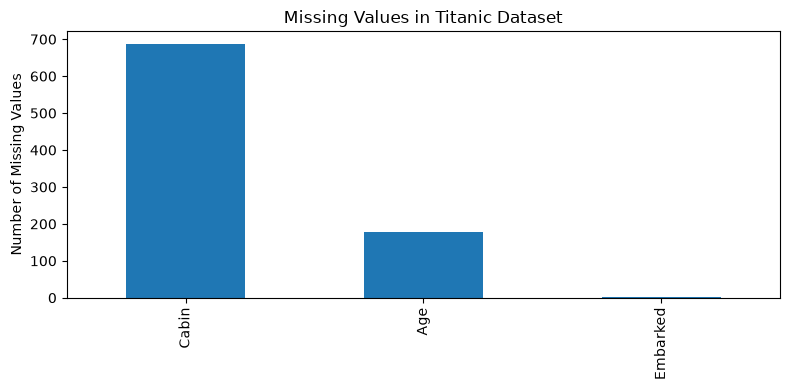

In [81]:
missing = missing_count[missing_count > 0].sort_values(ascending=False)

missing.plot(
    kind="bar",
    figsize=(8, 4),
    title="Missing Values in Titanic Dataset",
    ylabel="Number of Missing Values"
)

plt.tight_layout()
plt.show()

## 6. Decide How to Handle Each Column

The important part of missing-value handling is **not the code — it is the decision**.

For the Titanic training data:

- `Age` → numerical and moderately incomplete → **median imputation**
- `Embarked` → categorical with very few missing values → **mode imputation**
- `Cabin` → a very large proportion is missing → **do not blindly fill every cabin with the mode**; for this preprocessing exercise, we will drop it and later consider extracting useful information such as cabin deck as a feature.
- `Survived` → target column → should not be imputed; rows without a target would not be usable for supervised training.

## 7. Dropping Missing Rows — Demonstration

`dropna()` removes rows containing missing values.

This is useful to understand, but dropping all incomplete Titanic rows would discard too much useful data because several columns contain missing values.

In [82]:
df_drop_rows = df.dropna()

print("Original shape:", df.shape)
print("After dropna():", df_drop_rows.shape)

Original shape: (891, 12)
After dropna(): (183, 12)


## 8. Numerical Imputation — Age

For numerical data, common simple strategies are:

- **Mean** — appropriate when the distribution is reasonably symmetric.
- **Median** — more robust when the feature is skewed or contains outliers.

For `Age`, median imputation is a sensible baseline.

In [83]:
df_processed = df.copy()

age_median = df_processed["Age"].median()

df_processed["Age"] = df_processed["Age"].fillna(age_median)

print("Age median used for imputation:", age_median)
print("Remaining missing Age values:", df_processed["Age"].isnull().sum())

Age median used for imputation: 28.0
Remaining missing Age values: 0


## 9. Categorical Imputation — Embarked

For a categorical feature with only a small number of missing values, the **mode** is a simple baseline.

`mode()[0]` returns the most frequent category.

In [84]:
embarked_mode = df_processed["Embarked"].mode()[0]

df_processed["Embarked"] = df_processed["Embarked"].fillna(embarked_mode)

print("Embarked mode used:", embarked_mode)
print("Remaining missing Embarked values:", df_processed["Embarked"].isnull().sum())

Embarked mode used: S
Remaining missing Embarked values: 0


## 10. Handling Cabin

`Cabin` has a very high percentage of missing values in the Kaggle Titanic training data.

Instead of filling hundreds of missing cabin numbers with the same value, we will **drop the raw `Cabin` column for this notebook**.

Later, in **Feature Engineering**, we can revisit this information and create a more useful feature such as:

```text
Cabin → Deck
C85   → C
B28   → B
NaN   → Unknown
```

This is a good example of why preprocessing and feature engineering are connected.

In [85]:
df_processed = df_processed.drop(columns=["Cabin"])

df_processed.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## 11. Verify Missing Values

Always verify the result after preprocessing.

In [86]:
remaining_missing = df_processed.isnull().sum()

remaining_missing[remaining_missing > 0]

Series([], dtype: int64)

In [87]:
print("Total remaining missing values:",
      df_processed.isnull().sum().sum())

print("Final shape:", df_processed.shape)

Total remaining missing values: 0
Final shape: (891, 11)


## 12. Before vs After

In [88]:
before_after = pd.DataFrame({
    "Before": df.isnull().sum(),
    "After": df_processed.isnull().sum().reindex(df.columns, fill_value=0)
})

before_after[before_after["Before"] > 0]

,Before,After
Age,177,0
Cabin,687,0
Embarked,2,0


## 13. Important: Data Leakage

In a real ML project, do **not** calculate the median or mode using the entire dataset before splitting into training and test sets.

Correct workflow:

```text
Raw Data
   ↓
Train / Test Split
   ↓
Learn median/mode from TRAIN only
   ↓
Transform TRAIN
   ↓
Transform TEST using the same learned values
```

This prevents information from the test set from influencing the training process.

Later, use Scikit-learn's `SimpleImputer`, `ColumnTransformer`, and `Pipeline` to implement this correctly.

## 14. Save the Preprocessed Dataset

This creates a dataset that can be reused in the next preprocessing notebooks.

> We are keeping `Sex`, `Embarked`, and the other categorical columns for now because **Encoding** is the next stage.

In [89]:
output_path = "../dataset/titanic_missing_values_handled.csv"

df_processed.to_csv(output_path, index=False)

print(f"Saved: {output_path}")

Saved: ../dataset/titanic_missing_values_handled.csv


## Important Keynotes

- Use `isnull().sum()` to detect missing values.
- Always inspect both **missing count and percentage**.
- Do not automatically delete rows containing missing values.
- Use **median** as a robust baseline for numerical features such as `Age`.
- Use **mode** for categorical features such as `Embarked` when appropriate.
- A column with a very high missing rate, such as `Cabin`, may require dropping or feature engineering rather than simple imputation.
- Never impute the target variable just to make the dataset complete.
- Avoid **data leakage** by learning imputation values from training data only.

### Next

```text
Missing Values
      ↓
Outliers
      ↓
Encoding
      ↓
Scaling
      ↓
Feature Engineering
      ↓
ML-Ready Dataset
```